In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
scenarios = pd.read_csv('X_frequencies.csv')
scenarios.head()

,X,T_freq,L_freq
0,1,0.0,1.0
1,2,0.0,2.0
2,3,0.0,3.0
3,4,0.0,4.0
4,5,0.0,5.0


In [3]:
X = list(range(1,48))

In [4]:
cutoffs = [15,30,45,60]

#### Access by precinct

In [5]:
accessdf = pd.DataFrame() 
for i in X:
    for t in cutoffs:
        filename = './FrequencyMatrix_ByPrecinct/Uniform_ByPrecinct/TOD4_X'+str(i)+'_Uniform_T'+str(t)+'_jobs.csv'
        mydf = pd.read_csv(filename)
        mydf['cutoff'] = t
        mydf['X'] = i
        accessdf = accessdf.append(mydf)
accessdf.head()

,locality,Jobs,cutoff,X
0,BUSBY,2295.984982,15,1
1,MILLER,3283.443851,15,1
2,CASULA,1112.603664,15,1
3,CARTWRIGHT,5053.126890,15,1
4,HECKENBERG,1464.038413,15,1


In [6]:
len(accessdf)

7896

In [7]:
accessdf = accessdf.merge(scenarios, how='left', on='X')
accessdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq
0,BUSBY,2295.984982,15,1,0.0,1.0
1,MILLER,3283.443851,15,1,0.0,1.0
2,CASULA,1112.603664,15,1,0.0,1.0
3,CARTWRIGHT,5053.126890,15,1,0.0,1.0
4,HECKENBERG,1464.038413,15,1,0.0,1.0


In [8]:
accessdf.to_csv('Access_AllScenarios_Uniform.csv', index=False)

#### Liverpool access

In [9]:
livdf = pd.DataFrame() 
for i in X:
    for t in cutoffs:
        filename = './PWA_Liverpool/Uniform_Liverpool/TOD4_X'+str(i)+'_Uniform_T'+str(t)+'_jobs.csv'
        mydf = pd.read_csv(filename)
        mydf['cutoff'] = t
        mydf['X'] = i
        livdf = livdf.append(mydf)
livdf.head()

,V1,V2,cutoff,X
0,Liverpool,4675.974992,15,1
0,Liverpool,40539.922655,30,1
0,Liverpool,154535.993446,45,1
0,Liverpool,516845.375888,60,1
0,Liverpool,4508.858989,15,2


In [10]:
livdf = livdf.merge(scenarios, how='left', on='X')
livdf.head()

,V1,V2,cutoff,X,T_freq,L_freq
0,Liverpool,4675.974992,15,1,0.0,1.0
1,Liverpool,40539.922655,30,1,0.0,1.0
2,Liverpool,154535.993446,45,1,0.0,1.0
3,Liverpool,516845.375888,60,1,0.0,1.0
4,Liverpool,4508.858989,15,2,0.0,2.0


In [11]:
len(livdf)

188

In [12]:
livdf.columns = ['locality','Jobs','cutoff','X','T_freq','L_freq']
livdf.head()

,locality,Jobs,cutoff,X,T_freq,L_freq
0,Liverpool,4675.974992,15,1,0.0,1.0
1,Liverpool,40539.922655,30,1,0.0,1.0
2,Liverpool,154535.993446,45,1,0.0,1.0
3,Liverpool,516845.375888,60,1,0.0,1.0
4,Liverpool,4508.858989,15,2,0.0,2.0


In [13]:
livdf.to_csv('Access_LiverpoolLGA_Uniform.csv', index=False)

#### Append livdf to accessdf

In [14]:
len(accessdf)
accessdf = accessdf.append(livdf, ignore_index=False)
len(accessdf)

8084

### Local routes only vs. T-ways only

In [15]:
local15 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
local15 = local15.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

local30 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
local30 = local30.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

local45 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
local45 = local45.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

local60 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
local60 = local60.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

In [16]:
tway15 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
tway15 = tway15.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tway30 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
tway30 = tway30.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tway45 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
tway45 = tway45.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tway60 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
tway60 = tway60.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

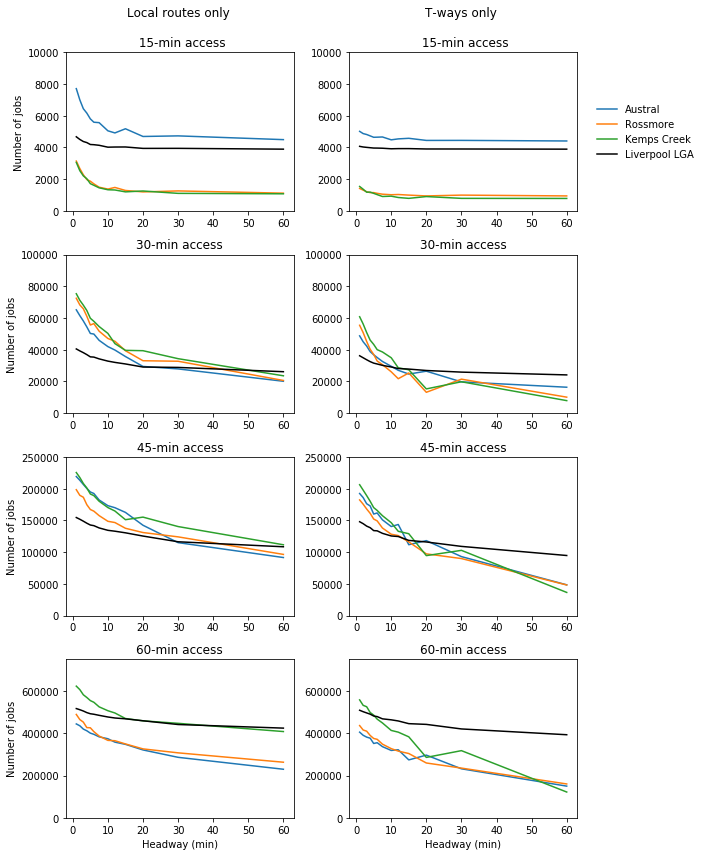

In [17]:
fig, ax = plt.subplots(nrows=4,ncols=2,figsize=(10,12))

ax[0,0].plot(local15.index, local15['AUSTRAL'], label = 'Austral')
ax[0,0].plot(local15.index, local15['ROSSMORE'], label = 'Rossmore')
ax[0,0].plot(local15.index, local15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,0].plot(local15.index, local15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,0].set_ylim(0,10000)
ax[0,0].set_ylabel('Number of jobs')
ax[0,0].set_title('Local routes only \n\n 15-min access')

ax[1,0].plot(local30.index, local30['AUSTRAL'], label = 'Austral')
ax[1,0].plot(local30.index, local30['ROSSMORE'], label = 'Rossmore')
ax[1,0].plot(local30.index, local30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,0].plot(local30.index, local30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,0].set_ylim(0,100000)
ax[1,0].set_ylabel('Number of jobs')
ax[1,0].set_title('30-min access')

ax[2,0].plot(local45.index, local45['AUSTRAL'], label = 'Austral')
ax[2,0].plot(local45.index, local45['ROSSMORE'], label = 'Rossmore')
ax[2,0].plot(local45.index, local45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,0].plot(local45.index, local45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,0].set_ylim(0,250000)
ax[2,0].set_ylabel('Number of jobs')
ax[2,0].set_title('45-min access')

ax[3,0].plot(local60.index, local60['AUSTRAL'], label = 'Austral')
ax[3,0].plot(local60.index, local60['ROSSMORE'], label = 'Rossmore')
ax[3,0].plot(local60.index, local60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,0].plot(local60.index, local60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,0].set_ylim(0,750000)
ax[3,0].set_ylabel('Number of jobs')
ax[3,0].set_xlabel('Headway (min)')
ax[3,0].set_title('60-min access')

ax[0,1].plot(tway15.index, tway15['AUSTRAL'], label = 'Austral')
ax[0,1].plot(tway15.index, tway15['ROSSMORE'], label = 'Rossmore')
ax[0,1].plot(tway15.index, tway15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,1].plot(tway15.index, tway15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,1].set_ylim(0,10000)
ax[0,1].set_title('T-ways only \n\n 15-min access')
lgd = ax[0,1].legend(bbox_to_anchor=(1.3, 0.5), loc='center', frameon=False)

ax[1,1].plot(tway30.index, tway30['AUSTRAL'], label = 'Austral')
ax[1,1].plot(tway30.index, tway30['ROSSMORE'], label = 'Rossmore')
ax[1,1].plot(tway30.index, tway30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,1].plot(tway30.index, tway30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,1].set_ylim(0,100000)
ax[1,1].set_title('30-min access')

ax[2,1].plot(tway45.index, tway45['AUSTRAL'], label = 'Austral')
ax[2,1].plot(tway45.index, tway45['ROSSMORE'], label = 'Rossmore')
ax[2,1].plot(tway45.index, tway45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,1].plot(tway45.index, tway45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,1].set_ylim(0,250000)
ax[2,1].set_title('45-min access')

ax[3,1].plot(tway60.index, tway60['AUSTRAL'], label = 'Austral')
ax[3,1].plot(tway60.index, tway60['ROSSMORE'], label = 'Rossmore')
ax[3,1].plot(tway60.index, tway60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,1].plot(tway60.index, tway60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,1].set_ylim(0,750000)
ax[3,1].set_xlabel('Headway (min)')
ax[3,1].set_title('60-min access')

fig.tight_layout()
plt.show()
fig.savefig('./Plots/Access_LocalVsTways_ByPrecinct.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

### Diagonal

In [18]:
diagonal15 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
diagonal15 = diagonal15.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')

diagonal30 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
diagonal30 = diagonal30.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')

diagonal45 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
diagonal45 = diagonal45.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')

diagonal60 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
diagonal60 = diagonal60.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')


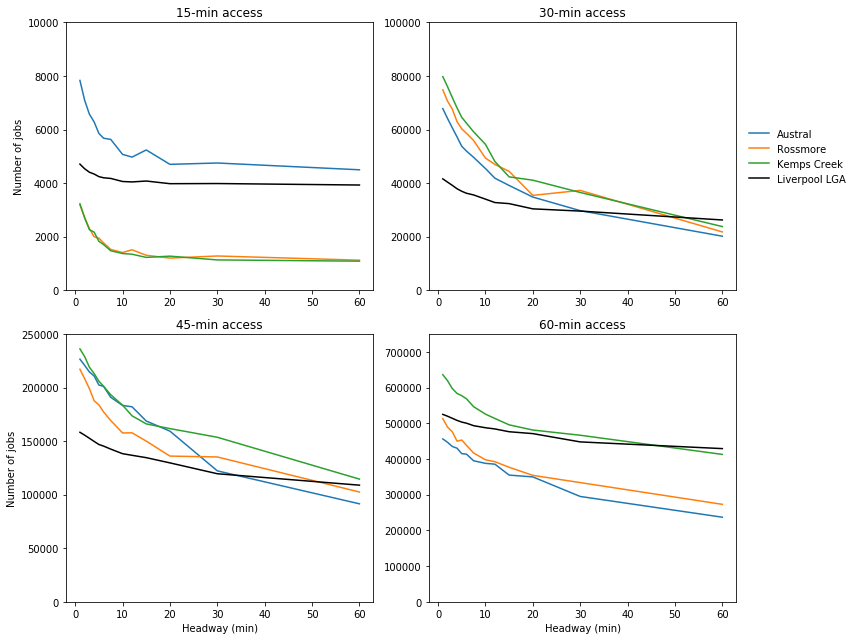

In [19]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(12,9))

ax[0,0].plot(diagonal15.index, diagonal15['AUSTRAL'], label = 'Austral')
ax[0,0].plot(diagonal15.index, diagonal15['ROSSMORE'], label = 'Rossmore')
ax[0,0].plot(diagonal15.index, diagonal15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,0].plot(diagonal15.index, diagonal15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,0].set_ylim(0,10000)
ax[0,0].set_ylabel('Number of jobs')
ax[0,0].set_title('15-min access')

ax[0,1].plot(diagonal30.index, diagonal30['AUSTRAL'], label = 'Austral')
ax[0,1].plot(diagonal30.index, diagonal30['ROSSMORE'], label = 'Rossmore')
ax[0,1].plot(diagonal30.index, diagonal30['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,1].plot(diagonal30.index, diagonal30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,1].set_ylim(0,100000)
ax[0,1].set_title('30-min access')
lgd = ax[0,1].legend(bbox_to_anchor=(1.2, 0.5), loc='center', frameon=False)

ax[1,0].plot(diagonal45.index, diagonal45['AUSTRAL'], label = 'Austral')
ax[1,0].plot(diagonal45.index, diagonal45['ROSSMORE'], label = 'Rossmore')
ax[1,0].plot(diagonal45.index, diagonal45['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,0].plot(diagonal45.index, diagonal45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,0].set_ylim(0,250000)
ax[1,0].set_ylabel('Number of jobs')
ax[1,0].set_xlabel('Headway (min)')
ax[1,0].set_title('45-min access')

ax[1,1].plot(diagonal60.index, diagonal60['AUSTRAL'], label = 'Austral')
ax[1,1].plot(diagonal60.index, diagonal60['ROSSMORE'], label = 'Rossmore')
ax[1,1].plot(diagonal60.index, diagonal60['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,1].plot(diagonal60.index, diagonal60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,1].set_ylim(0,750000)
ax[1,1].set_xlabel('Headway (min)')
ax[1,1].set_title('60-min access')

fig.tight_layout()
plt.show()
fig.savefig('./Plots/Access_Diagonal_ByPrecinct.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

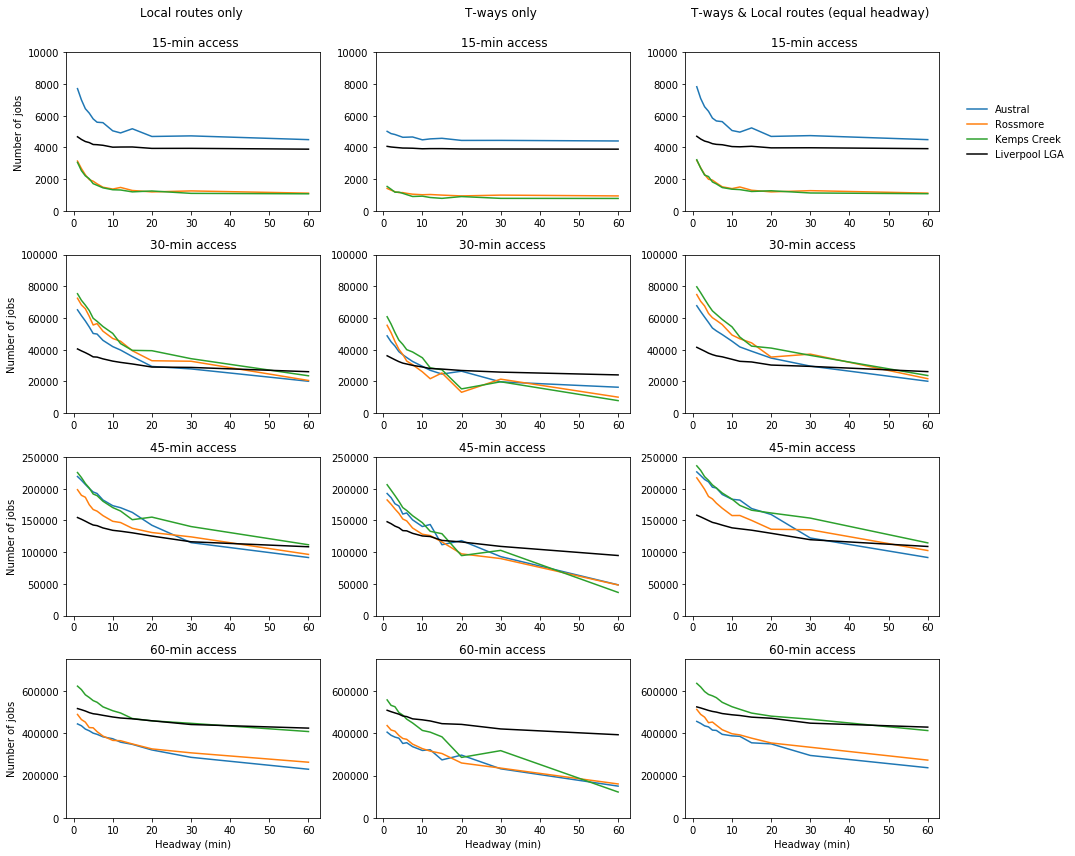

In [21]:
fig, ax = plt.subplots(nrows=4,ncols=3,figsize=(15,12))

ax[0,0].plot(local15.index, local15['AUSTRAL'], label = 'Austral')
ax[0,0].plot(local15.index, local15['ROSSMORE'], label = 'Rossmore')
ax[0,0].plot(local15.index, local15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,0].plot(local15.index, local15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,0].set_ylim(0,10000)
ax[0,0].set_ylabel('Number of jobs')
ax[0,0].set_title('Local routes only \n\n 15-min access')

ax[1,0].plot(local30.index, local30['AUSTRAL'], label = 'Austral')
ax[1,0].plot(local30.index, local30['ROSSMORE'], label = 'Rossmore')
ax[1,0].plot(local30.index, local30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,0].plot(local30.index, local30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,0].set_ylim(0,100000)
ax[1,0].set_ylabel('Number of jobs')
ax[1,0].set_title('30-min access')

ax[2,0].plot(local45.index, local45['AUSTRAL'], label = 'Austral')
ax[2,0].plot(local45.index, local45['ROSSMORE'], label = 'Rossmore')
ax[2,0].plot(local45.index, local45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,0].plot(local45.index, local45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,0].set_ylim(0,250000)
ax[2,0].set_ylabel('Number of jobs')
ax[2,0].set_title('45-min access')

ax[3,0].plot(local60.index, local60['AUSTRAL'], label = 'Austral')
ax[3,0].plot(local60.index, local60['ROSSMORE'], label = 'Rossmore')
ax[3,0].plot(local60.index, local60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,0].plot(local60.index, local60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,0].set_ylim(0,750000)
ax[3,0].set_ylabel('Number of jobs')
ax[3,0].set_xlabel('Headway (min)')
ax[3,0].set_title('60-min access')

ax[0,1].plot(tway15.index, tway15['AUSTRAL'], label = 'Austral')
ax[0,1].plot(tway15.index, tway15['ROSSMORE'], label = 'Rossmore')
ax[0,1].plot(tway15.index, tway15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,1].plot(tway15.index, tway15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,1].set_ylim(0,10000)
ax[0,1].set_title('T-ways only \n\n 15-min access')

ax[1,1].plot(tway30.index, tway30['AUSTRAL'], label = 'Austral')
ax[1,1].plot(tway30.index, tway30['ROSSMORE'], label = 'Rossmore')
ax[1,1].plot(tway30.index, tway30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,1].plot(tway30.index, tway30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,1].set_ylim(0,100000)
ax[1,1].set_title('30-min access')

ax[2,1].plot(tway45.index, tway45['AUSTRAL'], label = 'Austral')
ax[2,1].plot(tway45.index, tway45['ROSSMORE'], label = 'Rossmore')
ax[2,1].plot(tway45.index, tway45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,1].plot(tway45.index, tway45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,1].set_ylim(0,250000)
ax[2,1].set_title('45-min access')

ax[3,1].plot(tway60.index, tway60['AUSTRAL'], label = 'Austral')
ax[3,1].plot(tway60.index, tway60['ROSSMORE'], label = 'Rossmore')
ax[3,1].plot(tway60.index, tway60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,1].plot(tway60.index, tway60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,1].set_ylim(0,750000)
ax[3,1].set_xlabel('Headway (min)')
ax[3,1].set_title('60-min access')

ax[0,2].plot(diagonal15.index, diagonal15['AUSTRAL'], label = 'Austral')
ax[0,2].plot(diagonal15.index, diagonal15['ROSSMORE'], label = 'Rossmore')
ax[0,2].plot(diagonal15.index, diagonal15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,2].plot(diagonal15.index, diagonal15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,2].set_ylim(0,10000)
ax[0,2].set_title('T-ways & Local routes (equal headway) \n\n 15-min access')
lgd = ax[0,2].legend(bbox_to_anchor=(1.3, 0.5), loc='center', frameon=False)

ax[1,2].plot(diagonal30.index, diagonal30['AUSTRAL'], label = 'Austral')
ax[1,2].plot(diagonal30.index, diagonal30['ROSSMORE'], label = 'Rossmore')
ax[1,2].plot(diagonal30.index, diagonal30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,2].plot(diagonal30.index, diagonal30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,2].set_ylim(0,100000)
ax[1,2].set_title('30-min access')

ax[2,2].plot(diagonal45.index, diagonal45['AUSTRAL'], label = 'Austral')
ax[2,2].plot(diagonal45.index, diagonal45['ROSSMORE'], label = 'Rossmore')
ax[2,2].plot(diagonal45.index, diagonal45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,2].plot(diagonal45.index, diagonal45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,2].set_ylim(0,250000)
ax[2,2].set_title('45-min access')

ax[3,2].plot(diagonal60.index, diagonal60['AUSTRAL'], label = 'Austral')
ax[3,2].plot(diagonal60.index, diagonal60['ROSSMORE'], label = 'Rossmore')
ax[3,2].plot(diagonal60.index, diagonal60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,2].plot(diagonal60.index, diagonal60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,2].set_ylim(0,750000)
ax[3,2].set_xlabel('Headway (min)')
ax[3,2].set_title('60-min access')

fig.tight_layout()
plt.show()
fig.savefig('./Plots/Access_LocalVsTwaysVsDiagonal_ByPrecinct.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

### Fixed-variable

In [22]:
xrange_t = [27]+list(range(40,44))

tvar_lfix_15 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
tvar_lfix_15 = tvar_lfix_15.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tvar_lfix_30 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
tvar_lfix_30 = tvar_lfix_30.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tvar_lfix_45 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
tvar_lfix_45 = tvar_lfix_45.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')

tvar_lfix_60 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
tvar_lfix_60 = tvar_lfix_60.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')


In [23]:
xrange_l = [27]+list(range(44,48))

tfix_lvar_15 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==15)]
tfix_lvar_15 = tfix_lvar_15.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

tfix_lvar_30 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==30)]
tfix_lvar_30 = tfix_lvar_30.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

tfix_lvar_45 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==45)]
tfix_lvar_45 = tfix_lvar_45.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')

tfix_lvar_60 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==60)]
tfix_lvar_60 = tfix_lvar_60.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')


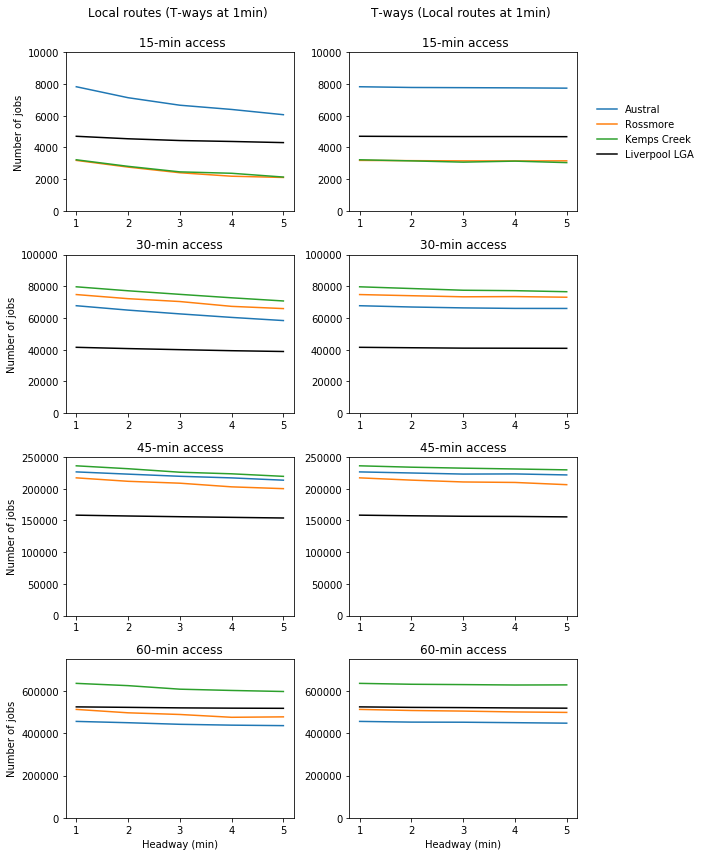

In [24]:
fig, ax = plt.subplots(nrows=4,ncols=2,figsize=(10,12))

ax[0,0].plot(tfix_lvar_15.index, tfix_lvar_15['AUSTRAL'], label = 'Austral')
ax[0,0].plot(tfix_lvar_15.index, tfix_lvar_15['ROSSMORE'], label = 'Rossmore')
ax[0,0].plot(tfix_lvar_15.index, tfix_lvar_15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,0].plot(tfix_lvar_15.index, tfix_lvar_15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,0].set_ylim(0,10000)
ax[0,0].set_ylabel('Number of jobs')
ax[0,0].set_title('Local routes (T-ways at 1min) \n\n 15-min access')

ax[1,0].plot(tfix_lvar_30.index, tfix_lvar_30['AUSTRAL'], label = 'Austral')
ax[1,0].plot(tfix_lvar_30.index, tfix_lvar_30['ROSSMORE'], label = 'Rossmore')
ax[1,0].plot(tfix_lvar_30.index, tfix_lvar_30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,0].plot(tfix_lvar_30.index, tfix_lvar_30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,0].set_ylim(0,100000)
ax[1,0].set_ylabel('Number of jobs')
ax[1,0].set_title('30-min access')

ax[2,0].plot(tfix_lvar_45.index, tfix_lvar_45['AUSTRAL'], label = 'Austral')
ax[2,0].plot(tfix_lvar_45.index, tfix_lvar_45['ROSSMORE'], label = 'Rossmore')
ax[2,0].plot(tfix_lvar_45.index, tfix_lvar_45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,0].plot(tfix_lvar_45.index, tfix_lvar_45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,0].set_ylim(0,250000)
ax[2,0].set_ylabel('Number of jobs')
ax[2,0].set_title('45-min access')

ax[3,0].plot(tfix_lvar_60.index, tfix_lvar_60['AUSTRAL'], label = 'Austral')
ax[3,0].plot(tfix_lvar_60.index, tfix_lvar_60['ROSSMORE'], label = 'Rossmore')
ax[3,0].plot(tfix_lvar_60.index, tfix_lvar_60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,0].plot(tfix_lvar_60.index, tfix_lvar_60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,0].set_ylim(0,750000)
ax[3,0].set_ylabel('Number of jobs')
ax[3,0].set_xlabel('Headway (min)')
ax[3,0].set_title('60-min access')

ax[0,1].plot(tvar_lfix_15.index, tvar_lfix_15['AUSTRAL'], label = 'Austral')
ax[0,1].plot(tvar_lfix_15.index, tvar_lfix_15['ROSSMORE'], label = 'Rossmore')
ax[0,1].plot(tvar_lfix_15.index, tvar_lfix_15['KEMPS CREEK'], label = 'Kemps Creek')
ax[0,1].plot(tvar_lfix_15.index, tvar_lfix_15['Liverpool'], label = 'Liverpool LGA', c='black')
ax[0,1].set_ylim(0,10000)
ax[0,1].set_title('T-ways (Local routes at 1min) \n\n 15-min access')
lgd = ax[0,1].legend(bbox_to_anchor=(1.3, 0.5), loc='center', frameon=False)

ax[1,1].plot(tvar_lfix_30.index, tvar_lfix_30['AUSTRAL'], label = 'Austral')
ax[1,1].plot(tvar_lfix_30.index, tvar_lfix_30['ROSSMORE'], label = 'Rossmore')
ax[1,1].plot(tvar_lfix_30.index, tvar_lfix_30['KEMPS CREEK'], label = 'Kemps Creek')
ax[1,1].plot(tvar_lfix_30.index, tvar_lfix_30['Liverpool'], label = 'Liverpool LGA', c='black')
ax[1,1].set_ylim(0,100000)
ax[1,1].set_title('30-min access')

ax[2,1].plot(tvar_lfix_45.index, tvar_lfix_45['AUSTRAL'], label = 'Austral')
ax[2,1].plot(tvar_lfix_45.index, tvar_lfix_45['ROSSMORE'], label = 'Rossmore')
ax[2,1].plot(tvar_lfix_45.index, tvar_lfix_45['KEMPS CREEK'], label = 'Kemps Creek')
ax[2,1].plot(tvar_lfix_45.index, tvar_lfix_45['Liverpool'], label = 'Liverpool LGA', c='black')
ax[2,1].set_ylim(0,250000)
ax[2,1].set_title('45-min access')

ax[3,1].plot(tvar_lfix_60.index, tvar_lfix_60['AUSTRAL'], label = 'Austral')
ax[3,1].plot(tvar_lfix_60.index, tvar_lfix_60['ROSSMORE'], label = 'Rossmore')
ax[3,1].plot(tvar_lfix_60.index, tvar_lfix_60['KEMPS CREEK'], label = 'Kemps Creek')
ax[3,1].plot(tvar_lfix_60.index, tvar_lfix_60['Liverpool'], label = 'Liverpool LGA', c='black')
ax[3,1].set_ylim(0,750000)
ax[3,1].set_xlabel('Headway (min)')
ax[3,1].set_title('60-min access')

fig.tight_layout()
plt.show()
fig.savefig('./Plots/Access_FixVar_ByPrecinct.pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

### No Tways, Local routes with varying frequencies

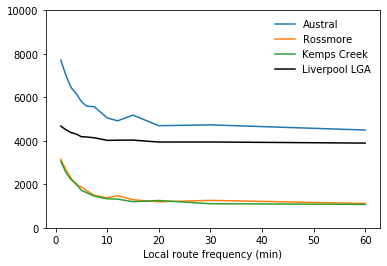

In [15]:
local15 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
local15 = local15.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(local15.index, local15['AUSTRAL'], label = 'Austral')
plt.plot(local15.index, local15['ROSSMORE'], label = 'Rossmore')
plt.plot(local15.index, local15['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(local15.index, local15['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,10000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/T0_L_15.pdf')

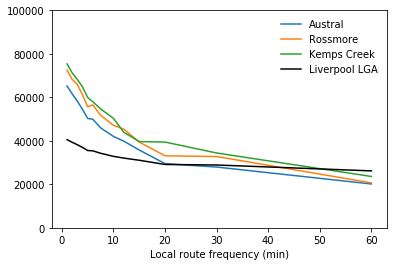

In [16]:
local30 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
local30 = local30.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(local30.index, local30['AUSTRAL'], label = 'Austral')
plt.plot(local30.index, local30['ROSSMORE'], label = 'Rossmore')
plt.plot(local30.index, local30['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(local30.index, local30['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,100000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/T0_L_30.pdf')

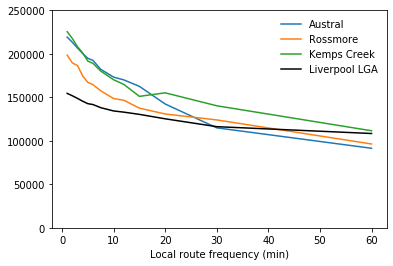

In [17]:
local45 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
local45 = local45.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(local45.index, local45['AUSTRAL'], label = 'Austral')
plt.plot(local45.index, local45['ROSSMORE'], label = 'Rossmore')
plt.plot(local45.index, local45['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(local45.index, local45['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,250000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/T0_L_45.pdf')

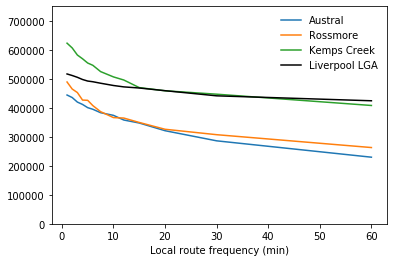

In [18]:
local60 = accessdf.loc[(accessdf['X']<14) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
local60 = local60.drop(['cutoff','X','T_freq'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(local60.index, local60['AUSTRAL'], label = 'Austral')
plt.plot(local60.index, local60['ROSSMORE'], label = 'Rossmore')
plt.plot(local60.index, local60['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(local60.index, local60['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,750000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/T0_L_60.pdf')

### No local routes, Tways with varying frequencies

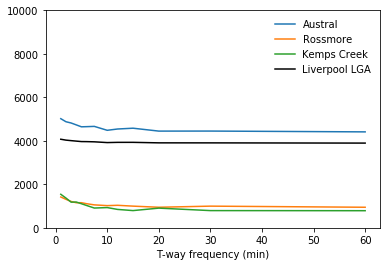

In [19]:
tway15 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
tway15 = tway15.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tway15.index, tway15['AUSTRAL'], label = 'Austral')
plt.plot(tway15.index, tway15['ROSSMORE'], label = 'Rossmore')
plt.plot(tway15.index, tway15['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tway15.index, tway15['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,10000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/L0_T_15.pdf')


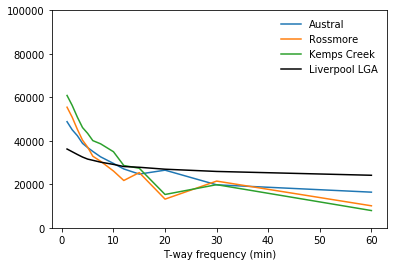

In [20]:
tway30 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
tway30 = tway30.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tway30.index, tway30['AUSTRAL'], label = 'Austral')
plt.plot(tway30.index, tway30['ROSSMORE'], label = 'Rossmore')
plt.plot(tway30.index, tway30['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tway30.index, tway30['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,100000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/L0_T_30.pdf')


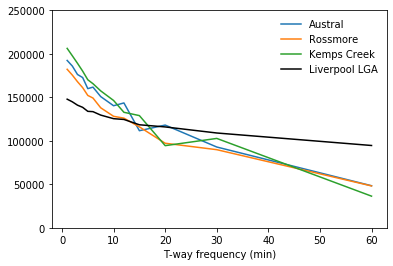

In [21]:
tway45 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
tway45 = tway45.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tway45.index, tway45['AUSTRAL'], label = 'Austral')
plt.plot(tway45.index, tway45['ROSSMORE'], label = 'Rossmore')
plt.plot(tway45.index, tway45['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tway45.index, tway45['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,250000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/L0_T_45.pdf')



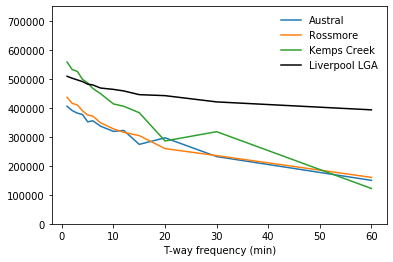

In [22]:
tway60 = accessdf.loc[((accessdf['X']>=14) & (accessdf['X']<=26)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
tway60 = tway60.drop(['cutoff','X','L_freq'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tway60.index, tway60['AUSTRAL'], label = 'Austral')
plt.plot(tway60.index, tway60['ROSSMORE'], label = 'Rossmore')
plt.plot(tway60.index, tway60['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tway60.index, tway60['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,750000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/L0_T_60.pdf')


### Tways and local routes with same frequencies

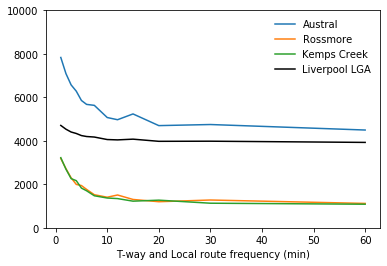

In [23]:
diagonal15 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
diagonal15 = diagonal15.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')
plt.plot(diagonal15.index, diagonal15['AUSTRAL'], label = 'Austral')
plt.plot(diagonal15.index, diagonal15['ROSSMORE'], label = 'Rossmore')
plt.plot(diagonal15.index, diagonal15['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(diagonal15.index, diagonal15['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way and Local route frequency (min)")
plt.ylim(0,10000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/Diagonal_15.pdf')


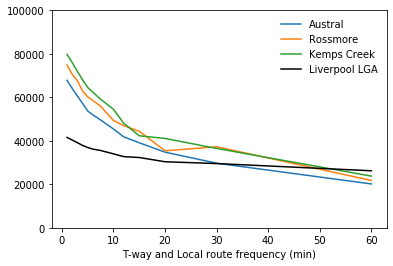

In [24]:
diagonal30 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
diagonal30 = diagonal30.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')
plt.plot(diagonal30.index, diagonal30['AUSTRAL'], label = 'Austral')
plt.plot(diagonal30.index, diagonal30['ROSSMORE'], label = 'Rossmore')
plt.plot(diagonal30.index, diagonal30['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(diagonal30.index, diagonal30['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way and Local route frequency (min)")
plt.ylim(0,100000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/Diagonal_30.pdf')


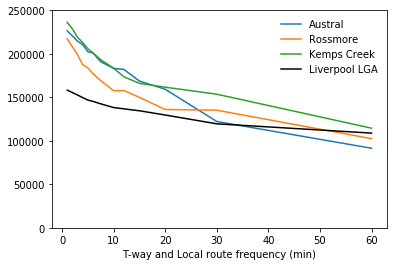

In [25]:
diagonal45 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
diagonal45 = diagonal45.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')
plt.plot(diagonal45.index, diagonal45['AUSTRAL'], label = 'Austral')
plt.plot(diagonal45.index, diagonal45['ROSSMORE'], label = 'Rossmore')
plt.plot(diagonal45.index, diagonal45['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(diagonal45.index, diagonal45['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way and Local route frequency (min)")
plt.ylim(0,250000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/Diagonal_45.pdf')


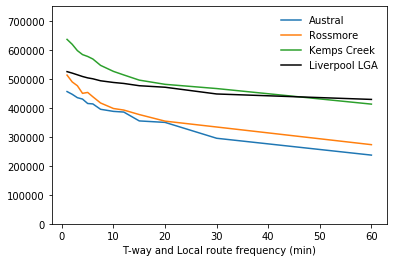

In [26]:
diagonal60 = accessdf.loc[((accessdf['X']>=27) & (accessdf['X']<=39)) 
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
diagonal60 = diagonal60.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index=['L_freq'],columns='locality',values='Jobs')
plt.plot(diagonal60.index, diagonal60['AUSTRAL'], label = 'Austral')
plt.plot(diagonal60.index, diagonal60['ROSSMORE'], label = 'Rossmore')
plt.plot(diagonal60.index, diagonal60['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(diagonal60.index, diagonal60['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way and Local route frequency (min)")
plt.ylim(0,750000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/Diagonal_60.pdf')


### Tways varying, local routes fixed at 1min

In [27]:
xrange_t = [27]+list(range(40,44))

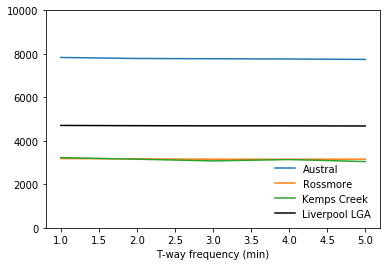

In [28]:
tvar_lfix_15 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==15)]
tvar_lfix_15 = tvar_lfix_15.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tvar_lfix_15.index, tvar_lfix_15['AUSTRAL'], label = 'Austral')
plt.plot(tvar_lfix_15.index, tvar_lfix_15['ROSSMORE'], label = 'Rossmore')
plt.plot(tvar_lfix_15.index, tvar_lfix_15['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tvar_lfix_15.index, tvar_lfix_15['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,10000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/L1_T_15.pdf')


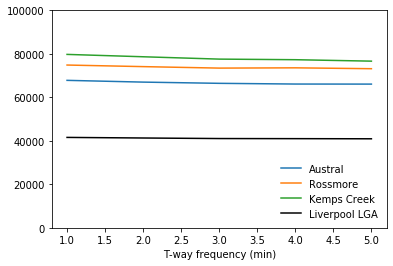

In [29]:
tvar_lfix_30 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==30)]
tvar_lfix_30 = tvar_lfix_30.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tvar_lfix_30.index, tvar_lfix_30['AUSTRAL'], label = 'Austral')
plt.plot(tvar_lfix_30.index, tvar_lfix_30['ROSSMORE'], label = 'Rossmore')
plt.plot(tvar_lfix_30.index, tvar_lfix_30['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tvar_lfix_30.index, tvar_lfix_30['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,100000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/L1_T_30.pdf')


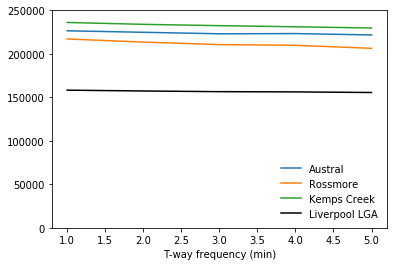

In [30]:
tvar_lfix_45 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==45)]
tvar_lfix_45 = tvar_lfix_45.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tvar_lfix_45.index, tvar_lfix_45['AUSTRAL'], label = 'Austral')
plt.plot(tvar_lfix_45.index, tvar_lfix_45['ROSSMORE'], label = 'Rossmore')
plt.plot(tvar_lfix_45.index, tvar_lfix_45['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tvar_lfix_45.index, tvar_lfix_45['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,250000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/L1_T_45.pdf')


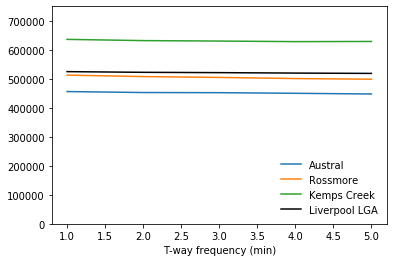

In [31]:
tvar_lfix_60 = accessdf.loc[(accessdf['X'].isin(xrange_t))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK','Liverpool']))
                       & (accessdf['cutoff']==60)]
tvar_lfix_60 = tvar_lfix_60.drop(['L_freq','cutoff','X'], axis=1).pivot_table(index='T_freq',columns='locality',values='Jobs')
plt.plot(tvar_lfix_60.index, tvar_lfix_60['AUSTRAL'], label = 'Austral')
plt.plot(tvar_lfix_60.index, tvar_lfix_60['ROSSMORE'], label = 'Rossmore')
plt.plot(tvar_lfix_60.index, tvar_lfix_60['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tvar_lfix_60.index, tvar_lfix_60['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("T-way frequency (min)")
plt.ylim(0,750000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/L1_T_60.pdf')


### Tways fixed at 1min, local routes varying

In [32]:
xrange_l = [27]+list(range(44,48))

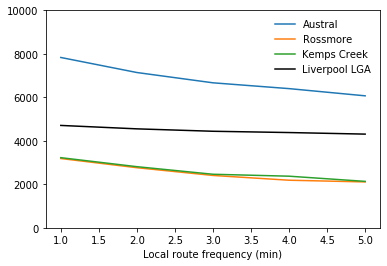

In [33]:
tfix_lvar_15 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==15)]
tfix_lvar_15 = tfix_lvar_15.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(tfix_lvar_15.index, tfix_lvar_15['AUSTRAL'], label = 'Austral')
plt.plot(tfix_lvar_15.index, tfix_lvar_15['ROSSMORE'], label = 'Rossmore')
plt.plot(tfix_lvar_15.index, tfix_lvar_15['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tfix_lvar_15.index, tfix_lvar_15['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,10000)
plt.legend(loc='upper right', frameon=False)
plt.savefig('./Plots/T1_L_15.pdf')


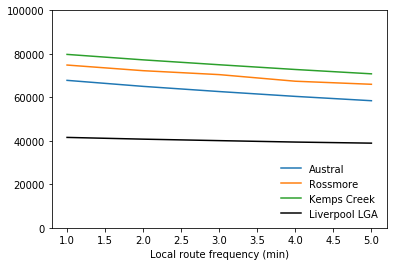

In [34]:
tfix_lvar_30 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==30)]
tfix_lvar_30 = tfix_lvar_30.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(tfix_lvar_30.index, tfix_lvar_30['AUSTRAL'], label = 'Austral')
plt.plot(tfix_lvar_30.index, tfix_lvar_30['ROSSMORE'], label = 'Rossmore')
plt.plot(tfix_lvar_30.index, tfix_lvar_30['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tfix_lvar_30.index, tfix_lvar_30['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,100000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/T1_L_30.pdf')


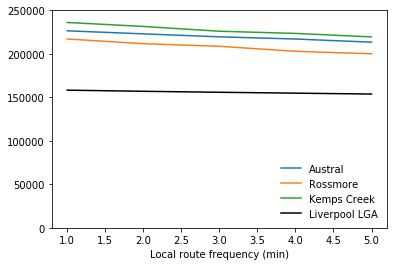

In [35]:
tfix_lvar_45 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==45)]
tfix_lvar_45 = tfix_lvar_45.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(tfix_lvar_45.index, tfix_lvar_45['AUSTRAL'], label = 'Austral')
plt.plot(tfix_lvar_45.index, tfix_lvar_45['ROSSMORE'], label = 'Rossmore')
plt.plot(tfix_lvar_45.index, tfix_lvar_45['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tfix_lvar_45.index, tfix_lvar_45['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,250000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/T1_L_45.pdf')


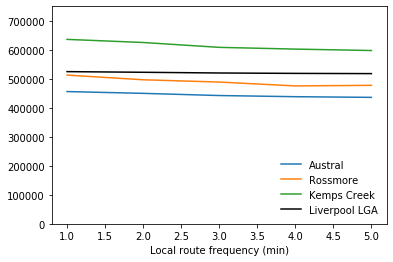

In [36]:
tfix_lvar_60 = accessdf.loc[(accessdf['X'].isin(xrange_l))
                       & (accessdf['locality'].isin(['AUSTRAL','ROSSMORE','KEMPS CREEK', 'Liverpool']))
                       & (accessdf['cutoff']==60)]
tfix_lvar_60 = tfix_lvar_60.drop(['T_freq','cutoff','X'], axis=1).pivot_table(index='L_freq',columns='locality',values='Jobs')
plt.plot(tfix_lvar_60.index, tfix_lvar_60['AUSTRAL'], label = 'Austral')
plt.plot(tfix_lvar_60.index, tfix_lvar_60['ROSSMORE'], label = 'Rossmore')
plt.plot(tfix_lvar_60.index, tfix_lvar_60['KEMPS CREEK'], label = 'Kemps Creek')
plt.plot(tfix_lvar_60.index, tfix_lvar_60['Liverpool'], label = 'Liverpool LGA', c='black')
plt.xlabel("Local route frequency (min)")
plt.ylim(0,750000)
plt.legend(loc='lower right', frameon=False)
plt.savefig('./Plots/T1_L_60.pdf')

